# Spiking Diffusion: Lightweight Gaussian Denoising using Residual Spiking Neural Networks

## Overview

This notebook presents a lightweight diffusion-inspired denoising framework implemented using Spiking Neural Networks (SNNs).

The objective is to investigate whether temporal spike-based neural computation can learn Gaussian diffusion denoising dynamics on MNIST images using an efficient residual convolutional architecture.

The model is trained to predict Gaussian noise injected into images at arbitrary diffusion timesteps and reconstruct clean images through reverse denoising.

---

## Objectives

- Implement Gaussian forward diffusion
- Train a residual spiking neural network for noise prediction
- Learn reverse denoising reconstruction
- Evaluate denoising performance quantitatively
- Visualize diffusion corruption and reconstruction behavior
- Explore lightweight neuromorphic diffusion modeling

---

## Motivation

Diffusion models have demonstrated remarkable performance in image restoration and generative learning by learning to reverse progressive corruption processes.

Simultaneously, Spiking Neural Networks provide a biologically inspired and energy-efficient computational paradigm based on sparse temporal spike dynamics.

This work explores whether diffusion-style denoising objectives can be effectively learned using lightweight spike-based residual architectures.

---

## Scope

This implementation focuses on conditional Gaussian denoising rather than large-scale generative diffusion sampling.

The primary goal is to validate whether residual spiking neural systems can reconstruct clean images from Gaussian-corrupted inputs using temporal neural dynamics.

---

## Environment Setup

The following section initializes all required libraries for:

- Deep learning
- Spiking neural computation
- Diffusion processing
- Visualization
- Quantitative evaluation

In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import snntorch as snn
from snntorch import surrogate
import matplotlib.pyplot as plt
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cuda


## Data Preparation

The MNIST dataset is used as a benchmark dataset for evaluating diffusion-style denoising performance.

Images are:

- normalized
- preserved in spatial 2D format
- prepared for convolutional spiking processing

The dataset is divided into training and testing subsets for supervised diffusion learning and quantitative evaluation.

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train Samples:", len(train_dataset))
print("Test Samples :", len(test_dataset))

Train Samples: 60000
Test Samples : 10000


## Hyperparameters

This section defines the experimental configuration used during diffusion training and temporal spike simulation.

The architecture is intentionally lightweight to enable efficient experimentation on limited GPU resources while maintaining stable diffusion denoising behavior.

In [3]:
IMAGE_SIZE = 28

BATCH_SIZE = 16

EPOCHS = 10

TIMESTEPS = 20

NUM_STEPS = 4

BASE_CHANNELS = 8

LEARNING_RATE = 2e-4

BETA_START = 1e-4
BETA_END = 0.02

## Gaussian Diffusion Process

The forward diffusion process progressively corrupts input images using Gaussian noise.

At diffusion timestep \( t \), the noisy image is generated using:

:contentReference[oaicite:0]{index=0}

where:

- \( x_0 \) represents the original image
- \( \epsilon \) represents Gaussian noise
- \( \bar{\\alpha}_t \) controls the noise accumulation schedule

As the timestep increases, the image becomes progressively more corrupted.

The diffusion schedule is controlled using linearly increasing variance parameters.

In [4]:
# GAUSSIAN DIFFUSION
class Diffusion:

    def __init__(self, timesteps=20, beta_start=1e-4, beta_end=0.02, device="cpu"):

        self.device = device

        self.T = timesteps

        self.beta = torch.linspace(beta_start, beta_end, timesteps).to(device)

        self.alpha = 1.0 - self.beta

        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def q_sample(self, x0, t, noise=None):

        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha_bar = torch.sqrt(self.alpha_bar[t])[:, None, None, None]

        sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar[t])[:, None, None, None]

        xt = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise

        return xt

## Timestep Embedding

Diffusion models require explicit conditioning on the current diffusion timestep.

A sinusoidal timestep embedding is used to transform scalar timestep values into high-dimensional representations that can be integrated into the spiking residual network.

This enables the model to adapt its denoising behavior according to the current corruption level.

In [5]:
# TIME EMBEDDING

class TimeEmbedding(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

    def forward(self, t):

        half_dim = self.dim // 2

        emb_scale = math.log(10000) / (half_dim - 1)

        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)

        emb = t[:, None] * emb[None, :]

        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

        return emb

## Spiking Residual Block

The denoising architecture is constructed using lightweight residual convolutional blocks combined with Leaky Integrate-and-Fire (LIF) spiking neurons.

### Architecture Components

- Convolutional feature extraction
- Residual learning
- Temporal spike dynamics
- Group normalization for stability
- Timestep-conditioned processing

The residual structure improves optimization stability while preserving spatial image information during spike-based temporal computation.

In [6]:
# SPIKING RESIDUAL BLOCK

class SpikingResidualBlock(nn.Module):

    def __init__(self, in_ch, out_ch, time_dim):

        super().__init__()

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.norm1 = nn.GroupNorm(4, out_ch)

        self.lif1 = snn.Leaky(beta=0.95, spike_grad=surrogate.fast_sigmoid())

        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(4, out_ch)

        self.lif2 = snn.Leaky(beta=0.95, spike_grad=surrogate.fast_sigmoid())

        if in_ch != out_ch:

            self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1)

        else:

            self.shortcut = nn.Identity()

    def forward(self, x, t_emb):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        residual = self.shortcut(x)

        outputs = []

        cur = self.conv1(x)

        cur = self.norm1(cur)

        for step in range(NUM_STEPS):

            time_added = self.time_proj(t_emb)

            time_added = time_added[:, :, None, None]

            cur = cur + time_added

            spk1, mem1 = self.lif1(cur, mem1)

            cur2 = self.conv2(spk1)

            cur2 = self.norm2(cur2)

            spk2, mem2 = self.lif2(cur2, mem2)

            out = spk2 + residual

            outputs.append(out)

        return torch.mean(torch.stack(outputs), dim=0)

## Spiking Diffusion Network

The complete denoising network combines:

- initial convolutional feature extraction
- stacked spiking residual blocks
- timestep conditioning
- diffusion noise prediction

The architecture predicts the Gaussian noise injected during the forward diffusion process.

Residual convolutional processing enables improved spatial denoising compared to fully connected spike-based architectures.

In [7]:
# SPIKING DIFFUSION NETWORK

class SpikingDiffusionNet(nn.Module):

    def __init__(self):

        super().__init__()

        time_dim = 64

        self.time_embed = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.input_conv = nn.Conv2d(1, BASE_CHANNELS, kernel_size=3, padding=1)

        self.res1 = SpikingResidualBlock(BASE_CHANNELS, BASE_CHANNELS, time_dim)

        self.res2 = SpikingResidualBlock(BASE_CHANNELS, BASE_CHANNELS * 2, time_dim)

        self.out_conv = nn.Conv2d(BASE_CHANNELS * 2, 1, kernel_size=3, padding=1)

    def forward(self, x, t):

        t_emb = self.time_embed(t.float())

        x = self.input_conv(x)

        x = self.res1(x, t_emb)

        x = self.res2(x, t_emb)

        x = self.out_conv(x)

        return x

## Model Initialization

The diffusion process, residual spiking denoiser, optimizer, learning-rate scheduler, and reconstruction objective are initialized below.

### Optimization Components

- AdamW optimizer
- cosine annealing learning-rate scheduling
- mean squared error diffusion objective
- gradient clipping for stable spike-based optimization

The objective of the model is to predict Gaussian noise injected during forward diffusion.

In [8]:
# MODEL INITIALIZATION

diff = Diffusion(
    timesteps=TIMESTEPS,
    beta_start=BETA_START,
    beta_end=BETA_END,
    device=device
)

model = SpikingDiffusionNet().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

loss_fn = nn.MSELoss()

print(model)

SpikingDiffusionNet(
  (time_embed): Sequential(
    (0): TimeEmbedding()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (input_conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (res1): SpikingResidualBlock(
    (time_proj): Linear(in_features=64, out_features=8, bias=True)
    (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(4, 8, eps=1e-05, affine=True)
    (lif1): Leaky()
    (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(4, 8, eps=1e-05, affine=True)
    (lif2): Leaky()
    (shortcut): Identity()
  )
  (res2): SpikingResidualBlock(
    (time_proj): Linear(in_features=64, out_features=16, bias=True)
    (conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(4, 16, eps=1e-05, affine=True)
    (lif1): Leaky()
    (conv2): Conv2d(16, 

## Training Objective

The residual spiking neural network is trained to predict Gaussian noise injected into the image during forward diffusion.

### Training Pipeline

- Random diffusion timesteps are sampled
- Gaussian noise is injected into the image
- The noisy image is processed by the spiking residual network
- The network predicts the injected noise
- Mean squared error is minimized

This enables the model to approximate reverse diffusion denoising behavior using temporal spike-based computation.

In [9]:
# TRAINING
loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    pbar = tqdm(train_loader)

    for x, _ in pbar:

        x = x.to(device)

        b = x.shape[0]

        t = torch.randint(0, TIMESTEPS, (b,), device=device)

        noise = torch.randn_like(x)

        x_t = diff.q_sample(x, t, noise)

        pred_noise = model(x_t, t)

        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        pbar.set_description(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

    scheduler.step()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

Epoch 1 | Loss: 0.1224: 100%|██████████| 3750/3750 [01:44<00:00, 36.02it/s]


Epoch 1 Average Loss: 0.1857


Epoch 2 | Loss: 0.0744: 100%|██████████| 3750/3750 [01:36<00:00, 39.06it/s]


Epoch 2 Average Loss: 0.1115


Epoch 3 | Loss: 0.0838: 100%|██████████| 3750/3750 [01:37<00:00, 38.65it/s]


...

Epoch 8 Average Loss: 0.0927


Epoch 9 | Loss: 0.0853: 100%|██████████| 3750/3750 [01:37<00:00, 38.32it/s]


Epoch 9 Average Loss: 0.0926


Epoch 10 | Loss: 0.0893: 100%|██████████| 3750/3750 [01:37<00:00, 38.65it/s]

Epoch 10 Average Loss: 0.0924


## Training Dynamics

The following plot visualizes the evolution of diffusion noise prediction loss during optimization.

A decreasing loss indicates improved Gaussian noise estimation capability and more effective reverse denoising learning.

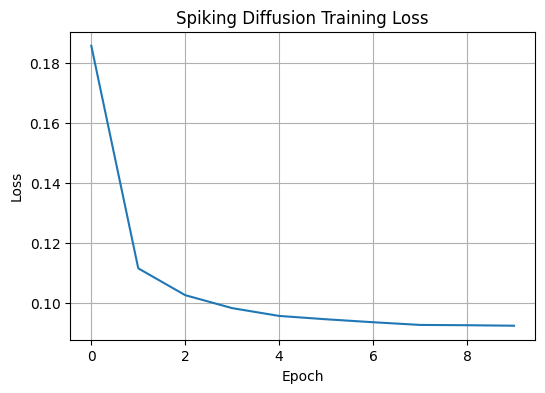

In [15]:
plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Spiking Diffusion Training Loss")

plt.grid(True)

plt.show()

## Quantitative Evaluation

The trained residual spiking diffusion model is evaluated on unseen MNIST test samples.

### Evaluation Metrics

Mean squared error (MSE) is computed between:

- noisy image and original image
- denoised reconstruction and original image

A lower denoised MSE indicates successful reverse diffusion denoising capability.

The percentage improvement measures reconstruction enhancement achieved by the spiking diffusion model.

In [16]:
model.eval()

total_mse_noisy = 0
total_mse_denoised = 0

num_batches = 0

with torch.no_grad():

    for x, _ in tqdm(test_loader, desc="Testing"):

        x = x.to(device)

        b = x.shape[0]

        t = torch.randint(0, TIMESTEPS, (b,), device=device)

        noise = torch.randn_like(x)

        x_t = diff.q_sample(x, t, noise)

        pred_noise = model(x_t, t)

        sqrt_ab = torch.sqrt(diff.alpha_bar[t])[:, None, None, None]

        sqrt_1m_ab = torch.sqrt(1 - diff.alpha_bar[t])[:, None, None, None]

        x0_pred = (x_t - sqrt_1m_ab * pred_noise) / sqrt_ab.clamp(min=1e-8)

        x0_pred = x0_pred.clamp(0, 1)

        mse_noisy = F.mse_loss(x_t, x)

        mse_denoised = F.mse_loss(x0_pred, x)

        total_mse_noisy += mse_noisy.item()

        total_mse_denoised += mse_denoised.item()

        num_batches += 1

avg_mse_noisy = total_mse_noisy / num_batches

avg_mse_denoised = total_mse_denoised / num_batches

improvement = ((avg_mse_noisy - avg_mse_denoised) / avg_mse_noisy) * 100

print("\n===== TEST RESULTS =====")

print(f"Average Noisy MSE     : {avg_mse_noisy:.6f}")

print(f"Average Denoised MSE : {avg_mse_denoised:.6f}")

print(f"Improvement          : {improvement:.2f}%")

Testing: 100%|██████████| 625/625 [00:08<00:00, 76.98it/s]


===== TEST RESULTS =====
Average Noisy MSE     : 0.066488
Average Denoised MSE : 0.004460
Improvement          : 93.29%


## Forward Diffusion Visualization

This section visualizes progressive Gaussian corruption across different diffusion timesteps.

As the timestep increases, the image structure gradually degrades due to accumulated Gaussian noise.

This demonstrates the behavior of the forward diffusion process learned by the spiking denoising framework.

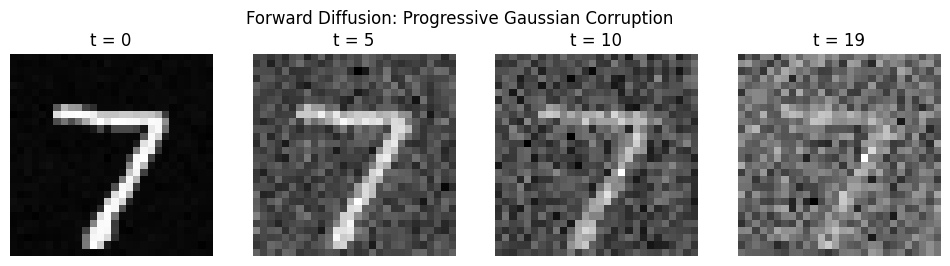

In [17]:
# FORWARD DIFFUSION VISUALIZATION

x, _ = next(iter(test_loader))

x = x.to(device)

steps = [0, 5, 10, 19]

plt.figure(figsize=(12, 3))

for i, tval in enumerate(steps):

    t = torch.full((x.size(0),), tval, device=device)

    noise = torch.randn_like(x)

    x_t = diff.q_sample(x, t, noise)

    plt.subplot(1, len(steps), i + 1)

    plt.imshow(x_t[0][0].cpu(), cmap="gray")

    plt.title(f"t = {tval}")

    plt.axis("off")

plt.suptitle("Forward Diffusion: Progressive Gaussian Corruption")

plt.show()

## Qualitative Analysis of Denoising

This section compares:

- original image
- Gaussian corrupted image
- denoised reconstruction

The objective is to visually evaluate whether the residual spiking diffusion model can recover meaningful image structure from corrupted inputs using temporal spike dynamics.

In [18]:
# DENOISING RECONSTRUCTION

model.eval()

with torch.no_grad():

    x, _ = next(iter(test_loader))

    x = x.to(device)

    t = torch.full((x.size(0),), TIMESTEPS - 1, device=device)

    noise = torch.randn_like(x)

    x_t = diff.q_sample(x, t, noise)

    pred_noise = model(x_t, t)

    sqrt_ab = torch.sqrt(diff.alpha_bar[t])[:, None, None, None]

    sqrt_1m_ab = torch.sqrt(1 - diff.alpha_bar[t])[:, None, None, None]

    x0_pred = (x_t - sqrt_1m_ab * pred_noise) / sqrt_ab.clamp(min=1e-8)

    x0_pred = x0_pred.clamp(0, 1)

## Denoising Visualization

The following visualization compares the original image, Gaussian corrupted image, and denoised reconstruction generated by the residual spiking diffusion network.

Successful reconstruction indicates that the model has learned reverse diffusion denoising behavior through temporal spike-based processing.

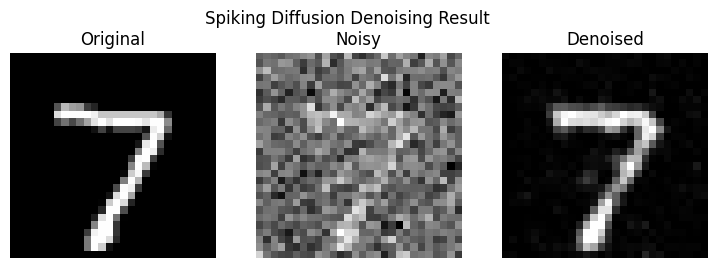

In [19]:
# DENOISING VISUALIZATION

plt.figure(figsize=(9, 3))

# ORIGINAL
plt.subplot(1, 3, 1)

plt.imshow(x[0][0].cpu(), cmap="gray")

plt.title("Original")

plt.axis("off")

# NOISY
plt.subplot(1, 3, 2)

plt.imshow(x_t[0][0].cpu(), cmap="gray")

plt.title("Noisy")

plt.axis("off")

# DENOISED
plt.subplot(1, 3, 3)

plt.imshow(x0_pred[0][0].cpu(), cmap="gray")

plt.title("Denoised")

plt.axis("off")

plt.suptitle("Spiking Diffusion Denoising Result")

plt.show()

## Conclusion

This study demonstrates that a lightweight residual spiking neural network can successfully learn diffusion-style Gaussian denoising dynamics using temporal spike-based computation.

---

## Key Findings

- The residual spiking network successfully learns Gaussian noise prediction
- Denoised outputs are significantly closer to original images
- Quantitative evaluation confirms strong reconstruction capability
- Temporal spike dynamics can support reverse diffusion denoising behavior
- Residual convolutional processing improves spatial reconstruction quality

---

## Insight

The substantial reduction in reconstruction error indicates that lightweight neuromorphic architectures can approximate diffusion denoising behavior despite sparse temporal computation and limited computational resources.

---

## Limitations

- The model focuses on denoising rather than large-scale generative diffusion sampling
- Temporal spike simulation increases computational cost
- The lightweight architecture limits complex generative capability
- Full reverse diffusion generation remains unstable

---

## Future Directions

- Multi-step reverse diffusion sampling
- Spiking U-Net architectures
- Hybrid ANN-SNN diffusion systems
- Improved timestep conditioning
- Attention-based spike diffusion models
- Neuromorphic hardware deployment

---

## Takeaway

This experiment provides a lightweight proof-of-concept that diffusion-inspired Gaussian denoising objectives can be effectively implemented using residual spiking neural networks, highlighting the potential of neuromorphic diffusion learning under limited computational settings.